# Linear Regression on Boston Housing Dataset

Run cells from top to bottom.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Linear Regression is a supervised Machine Learning algorithm used to predict continuous numerical values.

In [2]:
from sklearn.datasets import fetch_openml
# Load dataset

boston = fetch_openml(name="boston", version=1, as_frame=False)
# This line downloads and stores the Boston Housing dataset in variable boston.

In [3]:
data = pd.DataFrame(boston.data, columns=boston.feature_names)
# Creates a Pandas DataFrame using:
# boston.data → feature values
# boston.feature_names → column names

data = data.apply(pd.to_numeric, errors='coerce')
# Converts values into numbers.

data['PRICE'] = pd.to_numeric(boston.target, errors='coerce')
# Creates a new column named PRICE.

print("First 5 rows:")
print(data.head())

First 5 rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  


In [4]:
print("\nMissing values:")
print(data.isnull().sum())


Missing values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64


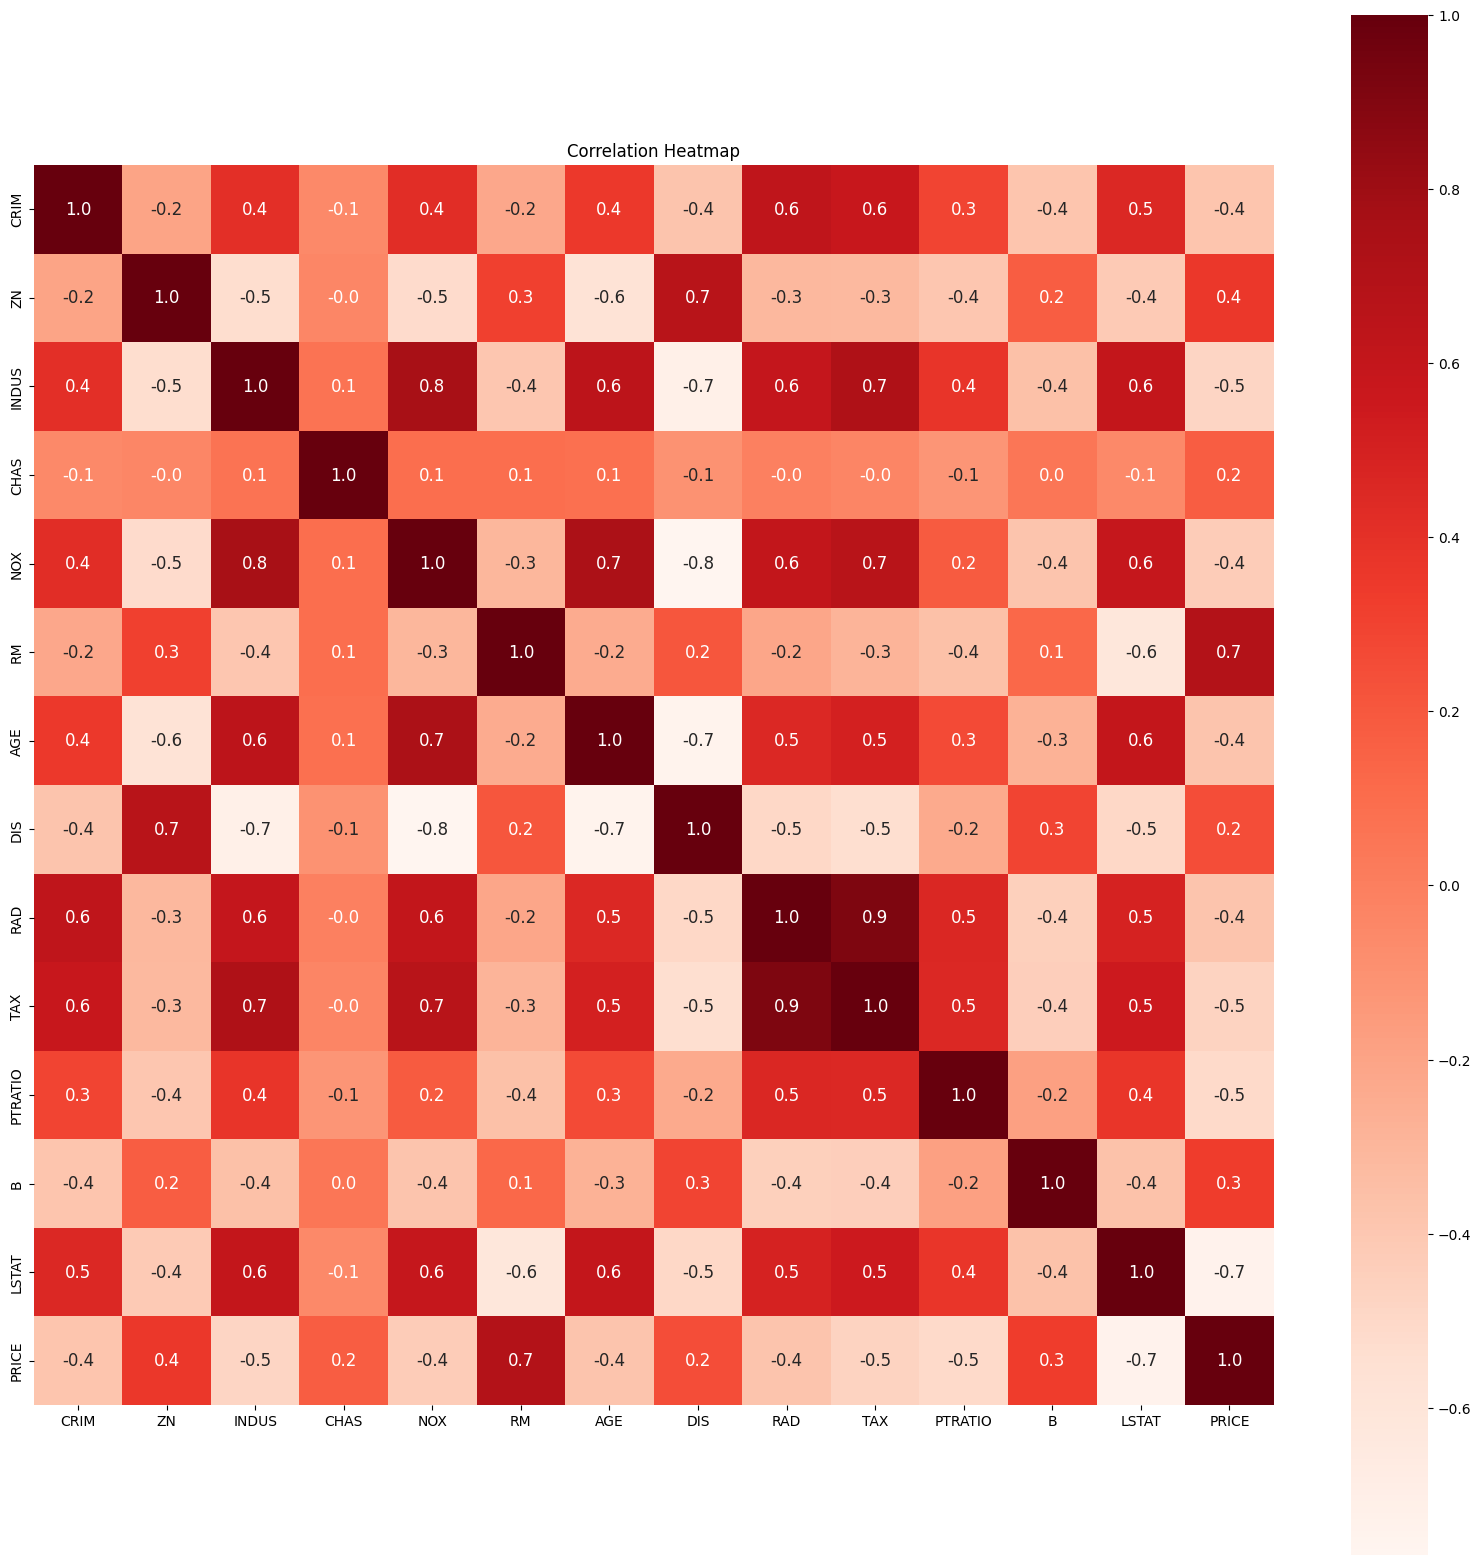

In [5]:
corr = data.corr()
# Correlation measures relationship between two variables.(-1 to +1)


plt.figure(figsize=(20,20))
# Creates plot area.


sns.heatmap(
    corr,
    cbar=True,
    square=True,
    fmt='.1f',
    annot=True,
    annot_kws={'size':12},
    cmap='Reds'
)
# Creates correlation heatmap.

plt.title("Correlation Heatmap")
plt.show()

# +ve(Dark) -> Highly Coreleted (when one value inc other also inc)

In [6]:
X = data.drop(['PRICE'], axis=1)
y = data['PRICE']

from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=0)
# Importing the functions inorder to divide the datasets

xtrain = np.array(xtrain, dtype=float)
xtest  = np.array(xtest, dtype=float)
ytrain = np.array(ytrain, dtype=float)
ytest  = np.array(ytest, dtype=float)

# Convert to NumPy Arrays

In [7]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(xtrain, ytrain)

# What fit() does

# The model:
# studies training data
# learns relationships between inputs and output
# calculates coefficients and intercept

ytrain_pred = lm.predict(xtrain)
# Uses trained model to predict prices for training data.

ytest_pred  = lm.predict(xtest)
# Predicts prices for unseen test data.

print("Predictions created successfully.")

Predictions created successfully.


In [8]:
from sklearn.metrics import mean_squared_error

mse_test = mean_squared_error(ytest, ytest_pred)
# Measures testing prediction error.

mse_train = mean_squared_error(ytrain, ytrain_pred)
# Measures training prediction error.

rmse = np.sqrt(mse_test)

r2 = lm.score(xtest, ytest)
# Calculates coefficient of determination (R² score).

print("\nModel Performance:")
print("MSE (Test):", mse_test)
print("MSE (Train):", mse_train)
print("RMSE:", rmse)
print("R-squared:", r2)


Model Performance:
MSE (Test): 33.44897999767657
MSE (Train): 19.326470203585725
RMSE: 5.783509315085138
R-squared: 0.5892223849182503


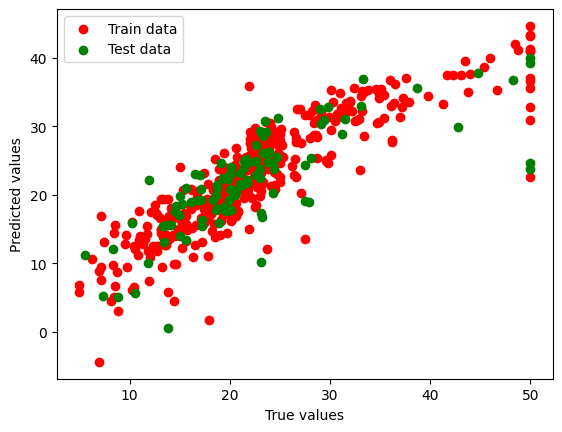

In [9]:
plt.scatter(ytrain, ytrain_pred, label='Train data',color='red')
# Creates scatter plot for training predictions.

plt.scatter(ytest, ytest_pred, label='Test data',color='green')
# Creates scatter plot for testing predictions.

plt.xlabel('True values')
plt.ylabel('Predicted values')

plt.legend()
# Displays legend box

plt.show()

In [10]:
testdata = np.array([[0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.09,1.0,296.0,15.3,396.9,4.98]], dtype=float)

test_pred = lm.predict(testdata)

print("\nCustom Test Prediction:")
print(test_pred)


Custom Test Prediction:
[30.49949836]


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

print(X_train.shape)
print(X_test.shape)

(404, 13)
(102, 13)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

In [13]:
import pandas as pd

sample_data = [[
    0.00632, 18.0, 2.31, 0.0, 0.538, 6.575, 65.2, 4.09, 1.0, 296.0, 15.3, 396.9, 4.98
]]

sample_df = pd.DataFrame(sample_data, columns=X.columns)

price = model.predict(sample_df)
print("Predicted selling price for house: ${:.2f}".format(price[0]))

Predicted selling price for house: $30.23
